# Report Summary — H2 VQE Quantum Chemistry Project

This notebook implements the Variational Quantum Eigensolver (VQE) for the hydrogen molecule (H2) as part of the hackathon theme:

"Healthcare & Life Sciences – Small Molecular Drug Discovery using Quantum Computing."

Although H2 is the simplest molecule, the workflow used here scales directly to drug-relevant molecules.

-------------------------------------------------------------------------------

## 1. Objective

- Construct the molecular Hamiltonian using Qiskit Nature
- Encode the fermionic Hamiltonian into qubits
- Solve for the ground state using VQE
- Compare against exact diagonalization
- Generate:
  - Potential Energy Curve (PEC)
  - Error metrics and analysis
  - CSV and Markdown summaries
  - A complete hackathon-ready report

-------------------------------------------------------------------------------

## 2. Methods Used

Hamiltonian Construction:
- PySCF backend via Qiskit Nature
- STO-3G basis
- H–H distances from 0.4 Å to 2.0 Å

Qubit Mapping:
- Jordan–Wigner encoding
- Optional Z2 tapering to reduce qubit count

Ansatz:
- TwoLocal hardware-efficient ansatz
- Decomposed into primitive gates
- Increased repetitions when tapered qubit count is small

Optimizer Strategy:
- Automatic fallback sequence:
  - L-BFGS-B
  - SLSQP
  - COBYLA
- Multiple random restarts per distance point

Exact Solver:
- Dense diagonalization of the qubit Hamiltonian
- Used as the reference for all comparisons

-------------------------------------------------------------------------------

## 3. Key Results

- Accurate potential energy curve for H2
- VQE energies extremely close to exact values
- Error metrics computed:
  - Absolute error
  - Percent error
  - RMS error
  - Max absolute error
  - Timing and optimizer info per run

-------------------------------------------------------------------------------

## 4. Visual Output

All plots are saved to the folder:

results/plots/

The main output is the potential energy curve:
- Exact diagonalization curve
- VQE curve (best across restarts)
- Shaded error region

Each plot is saved with a timestamped filename.

-------------------------------------------------------------------------------

## 5. Tables and Summaries

Tabular outputs are saved in:

results/tables/

This includes:
- Complete CSV table
- Sorted CSV (largest errors first)
- Markdown summary file containing:
  - RMS error
  - MAE
  - Max error
  - Signed error
  - Per-distance first few results

-------------------------------------------------------------------------------

## 6. Relevance to Drug Discovery

Accurate molecular energies are essential for:
- Binding energy prediction
- Reaction pathway modeling
- Studying functional groups and fragments
- Molecular simulation beyond classical limits

VQE enables:
- Reduced qubit usage
- Compatibility with noisy hardware
- A scalable path toward simulating drug-relevant molecules

The techniques here (tapering, optimizer sequencing, restarts) generalize to larger systems.

-------------------------------------------------------------------------------

## 7. Future Work

- Use more expressive ansatz circuits (UCCSD, ADAPT-VQE)
- Explore advanced encodings (Parity, Bravyi–Kitaev)
- Apply the workflow to small drug-like molecules
- Run experiments on real quantum hardware
- Add automated batching and parameter sweeps

-------------------------------------------------------------------------------

## Conclusion

This notebook forms a complete and reproducible VQE simulation workflow.
It establishes a strong foundation for applying quantum computing to realistic problems in quantum chemistry and drug discovery.


In [ ]:
# Cell 1 — environment & import check
import sys
import qiskit
import qiskit_nature
import pyscf

print("Python:", sys.version.splitlines()[0])
print("Qiskit:", getattr(qiskit, "__qiskit_version__", getattr(qiskit, "__version__", "unknown")))
print("Qiskit Nature:", qiskit_nature.__version__)
print("PySCF:", pyscf.__version__)


Python: 3.10.19 (main, Oct 21 2025, 16:43:05) [GCC 11.2.0]
Qiskit: 2.2.3
Qiskit Nature: 0.7.2
PySCF: 2.11.0


In [1]:
# Cell 2 (robust) — build H2 Hamiltonian and map to qubits (tries multiple API layouts)
import traceback
from pprint import pprint

r = 0.74  # H-H distance (Å)
geometry = f"H 0 0 0; H 0 0 {r}"
basis = "sto3g"

print("Building H2 at distance =", r, "Å with basis", basis)
print("Trying multiple Qiskit-Nature import layouts to be compatible with 0.5+ / 0.7+...")

fermionic_op = None
qubit_op = None
num_qubits = None

# Try several known import patterns / APIs
attempts = []

# Attempt A: modern Qiskit-Nature 0.7+ pattern (second_q.drivers, DistanceUnit)
try:
    from qiskit_nature.units import DistanceUnit
    from qiskit_nature.second_q.drivers import PySCFDriver
    print("Using qiskit_nature.second_q.drivers.PySCFDriver + DistanceUnit")
    driver = PySCFDriver(atom=geometry, unit=DistanceUnit.ANGSTROM, basis=basis)
    problem = driver.run()
    # modern result: problem may be an ElectronicStructureResult-like object
    try:
        # many modern tutorials: problem.hamiltonian or problem.second_q_ops()
        if hasattr(problem, "hamiltonian"):
            fermionic_op = problem.hamiltonian
        elif hasattr(problem, "second_q_ops"):
            ops = problem.second_q_ops()
            fermionic_op = ops[0]
        else:
            # some versions return a Problem object where you call problem.second_q_ops()
            fermionic_op = problem
    except Exception:
        fermionic_op = problem
    attempts.append("A ok")
except Exception as e:
    attempts.append(("A failed", repr(e)))
    # traceback.print_exc()

# Attempt B: older-ish pattern (qiskit_nature.drivers)
if fermionic_op is None:
    try:
        from qiskit_nature.drivers import PySCFDriver
        from qiskit_nature.units import DistanceUnit
        print("Using qiskit_nature.drivers.PySCFDriver + DistanceUnit")
        driver = PySCFDriver(atom=geometry, unit=DistanceUnit.ANGSTROM, basis=basis)
        problem = driver.run()
        ops = problem.second_q_ops()
        fermionic_op = ops[0]
        attempts.append("B ok")
    except Exception as e:
        attempts.append(("B failed", repr(e)))

# Attempt C: older tutorial style using ElectronicStructureProblem + converter
if fermionic_op is None:
    try:
        from qiskit_nature.second_q.drivers import PySCFDriver
        from qiskit_nature.second_q.problems import ElectronicStructureProblem
        from qiskit_nature.units import DistanceUnit
        print("Using second_q.drivers + ElectronicStructureProblem")
        driver = PySCFDriver(atom=geometry, unit=DistanceUnit.ANGSTROM, basis=basis)
        problem = ElectronicStructureProblem(driver)
        ops = problem.second_q_ops()
        fermionic_op = ops[0]
        attempts.append("C ok")
    except Exception as e:
        attempts.append(("C failed", repr(e)))

# If still none, show failure attempts
if fermionic_op is None:
    print("Failed to obtain fermionic operator. Attempts summary:")
    pprint(attempts)
    raise RuntimeError("Could not build fermionic operator from qiskit_nature with available imports. See attempts above.")

# At this point fermionic_op should be a second-quantized operator object (or wrapper)
print("Fermionic operator obtained (type):", type(fermionic_op))

# Map fermionic -> qubits using a mapper (try Jordan-Wigner / QubitConverter variants)
mapped = False
map_attempts = []
try:
    # Try modern mapper usage
    from qiskit_nature.second_q.mappers import JordanWignerMapper
    print("Mapping using JordanWignerMapper from qiskit_nature.second_q.mappers")
    mapper = JordanWignerMapper()
    # fermionic_op may be an object with .second_q_op() or already be the operator
    try:
        raw_ferm = fermionic_op.second_q_op()
    except Exception:
        raw_ferm = fermionic_op
    qubit_op = mapper.map(raw_ferm)
    num_qubits = qubit_op.num_qubits
    map_attempts.append("mapper modern ok")
    mapped = True
except Exception as e:
    map_attempts.append(("mapper modern failed", repr(e)))

if not mapped:
    try:
        # Try the QubitConverter path (older API)
        from qiskit_nature.converters.second_quantization import QubitConverter
        from qiskit_nature.mappers.second_quantization import JordanWignerMapper as OldJW
        print("Mapping using QubitConverter + OldJW mapper")
        converter = QubitConverter(OldJW())
        raw_ferm = getattr(fermionic_op, "second_q_op", lambda: fermionic_op)()
        qubit_op = converter.convert(raw_ferm)
        num_qubits = qubit_op.num_qubits
        map_attempts.append("QubitConverter ok")
        mapped = True
    except Exception as e:
        map_attempts.append(("QubitConverter failed", repr(e)))

if not mapped:
    print("Mapping attempts summary:")
    pprint(map_attempts)
    raise RuntimeError("Failed to map fermionic operator to qubits with available mappers.")

# Print short representations (truncated for readability)
print("\nMapped qubit operator (first 1200 chars):")
s = str(qubit_op)
print(s[:1200])

print("\nNumber of qubits required:", num_qubits)


Building H2 at distance = 0.74 Å with basis sto3g
Trying multiple Qiskit-Nature import layouts to be compatible with 0.5+ / 0.7+...
Using qiskit_nature.second_q.drivers.PySCFDriver + DistanceUnit
Fermionic operator obtained (type): <class 'qiskit_nature.second_q.hamiltonians.electronic_energy.ElectronicEnergy'>
Mapping using JordanWignerMapper from qiskit_nature.second_q.mappers

Mapped qubit operator (first 1200 chars):
SparsePauliOp(['IIII', 'IIIZ', 'IIZI', 'IIZZ', 'IZII', 'IZIZ', 'ZIII', 'ZIIZ', 'YYYY', 'XXYY', 'YYXX', 'XXXX', 'IZZI', 'ZIZI', 'ZZII'],
              coeffs=[-0.81217061+0.j,  0.17141283+0.j, -0.22343154+0.j,  0.12062523+0.j,
  0.17141283+0.j,  0.16868898+0.j, -0.22343154+0.j,  0.16592785+0.j,
  0.04530262+0.j,  0.04530262+0.j,  0.04530262+0.j,  0.04530262+0.j,
  0.16592785+0.j,  0.17441288+0.j,  0.12062523+0.j])

Number of qubits required: 4


In [11]:
# Cell 3 — Exact diagonalization (electronic + nuclear repulsion -> TOTAL energy)
import numpy as np

# qubit_op should exist from Cell 2 (mapped qubit operator)
try:
    qubit_op
except NameError:
    raise RuntimeError("qubit_op not found. Run Cell 2 (build Hamiltonian) first.")

# Convert to dense matrix (try the common paths)
mat = None
try:
    mat = qubit_op.to_matrix()
    method = "qubit_op.to_matrix()"
except Exception:
    try:
        from qiskit.quantum_info import Operator
        mat = Operator(qubit_op).data
        method = "QuantumInfo.Operator(...)"
    except Exception as e:
        raise RuntimeError("Failed to convert qubit_op to dense matrix: " + str(e))

mat = np.array(mat, dtype=complex)

# Diagonalize
evals = np.linalg.eigvalsh(mat)
evals_sorted = np.sort(evals)
electronic_gs = float(evals_sorted[0].real)

# Try to read nuclear repulsion energy from 'problem' (many API variants)
nuc = None
if 'problem' in globals():
    if hasattr(problem, "nuclear_repulsion_energy"):
        nuc = problem.nuclear_repulsion_energy
    elif hasattr(problem, "nuclear_repulsion"):
        nuc = problem.nuclear_repulsion
    elif hasattr(problem, "driver_result") and hasattr(problem.driver_result, "nuclear_repulsion_energy"):
        nuc = problem.driver_result.nuclear_repulsion_energy

total = electronic_gs + (nuc if nuc is not None else 0.0)

# Print nicely
print(f"Matrix conversion method used: {method}")
print("\nLowest electronic eigenvalues (first 6, Ha):")
for v in evals_sorted[:6]:
    print(f"  {v:.9f}")

print(f"\nExact electronic ground energy (qubit op) = {electronic_gs:.9f} Ha")
if nuc is not None:
    print(f"Nuclear repulsion energy                  = {nuc:.9f} Ha")
else:
    print("Nuclear repulsion energy                  = (not found in 'problem' object)")

print(f"Exact TOTAL molecular energy              = {total:.9f} Ha")


Matrix conversion method used: qubit_op.to_matrix()

Lowest electronic eigenvalues (first 6, Ha):
  -1.852388174
  -1.253309787
  -1.253309787
  -1.245877696
  -1.245877696
  -1.245877696

Exact electronic ground energy (qubit op) = -1.852388174 Ha
Nuclear repulsion energy                  = 0.715104339 Ha
Exact TOTAL molecular energy              = -1.137283834 Ha


In [12]:
# Cell 4 — Final stable VQE implementation (Aer + EstimatorV2 + decomposed ansatz)

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Aer + Estimator
from qiskit_aer import Aer
from qiskit_aer.primitives import EstimatorV2

# VQE + optimizer (works on qiskit_algorithms or legacy API)
try:
    from qiskit_algorithms.minimum_eigensolvers import VQE
    from qiskit_algorithms.optimizers import COBYLA
except Exception:
    from qiskit.algorithms.minimum_eigensolvers import VQE
    from qiskit.algorithms.optimizers import COBYLA

from qiskit.circuit.library import TwoLocal

# Ensure qubit_op exists
try:
    qubit_op
except NameError:
    raise RuntimeError("qubit_op not found. Run Cell 2 first.")

# Build estimator (backend-optional depending on version)
backend = Aer.get_backend("aer_simulator")
try:
    estimator = EstimatorV2(backend=backend)
    print("EstimatorV2 initialized with backend.")
except TypeError:
    estimator = EstimatorV2()
    print("EstimatorV2 initialized without backend.")

# Build ansatz (RY + CX) and fully decompose to primitive gates for Aer
nq = qubit_op.num_qubits
ansatz = TwoLocal(
    num_qubits=nq,
    rotation_blocks="ry",
    entanglement_blocks="cx",
    reps=1,
    insert_barriers=False
)

# Decompose repeatedly to ensure Aer sees only primitive instructions
for _ in range(6):
    if hasattr(ansatz, "decompose"):
        ansatz = ansatz.decompose()

print("Ansatz instruction count:", len(ansatz.data))

optimizer = COBYLA(maxiter=200)

vqe = VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=optimizer
)

print("Running VQE...")
result = vqe.compute_minimum_eigenvalue(qubit_op)
electronic_vqe = float(result.eigenvalue.real)

# Retrieve nuclear repulsion from problem if available
nuc = None
if 'problem' in globals():
    if hasattr(problem, "nuclear_repulsion_energy"):
        nuc = problem.nuclear_repulsion_energy
    elif hasattr(problem, "nuclear_repulsion"):
        nuc = problem.nuclear_repulsion
    elif hasattr(problem, "driver_result") and hasattr(problem.driver_result, "nuclear_repulsion_energy"):
        nuc = problem.driver_result.nuclear_repulsion_energy

total_vqe = electronic_vqe + (nuc if nuc is not None else 0.0)

# Print results
print(f"\nVQE electronic energy = {electronic_vqe:.9f} Ha")
if nuc is not None:
    print(f"Nuclear repulsion    = {nuc:.9f} Ha")
print(f"VQE TOTAL molecular energy = {total_vqe:.9f} Ha")

print("\n(VQE finished successfully.)")


EstimatorV2 initialized without backend.
Ansatz instruction count: 14
Running VQE...


/tmp/ipykernel_22610/3405953341.py:37: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ansatz = TwoLocal(



VQE electronic energy = -1.831863636 Ha
Nuclear repulsion    = 0.715104339 Ha
VQE TOTAL molecular energy = -1.116759297 Ha

(VQE finished successfully.)


Repo root detected as: /mnt/c/Users/rachi/OneDrive/Desktop/H2-VQE-Quantum-Chemistry/H2-VQE-Quantum-Chemistry
Plots will be saved to: /mnt/c/Users/rachi/OneDrive/Desktop/H2-VQE-Quantum-Chemistry/H2-VQE-Quantum-Chemistry/results/plots
Tables will be saved to: /mnt/c/Users/rachi/OneDrive/Desktop/H2-VQE-Quantum-Chemistry/H2-VQE-Quantum-Chemistry/results/tables

Starting robust EstimatorV2 VQE sweep with restarts...

--- r = 0.40 Å ---
  target qubits: 4 | taper: no


/tmp/ipykernel_22610/2557918980.py:197: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ansatz = TwoLocal(num_qubits=nq, rotation_blocks="ry", entanglement_blocks="cx", reps=reps)
/tmp/ipykernel_22610/2557918980.py:197: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ansatz = TwoLocal(num_qubits=nq, rotation_blocks="ry", entanglement_blocks="cx", reps=reps)
/tmp/ipykernel_22610/2557918980.py:197: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ansatz = TwoLocal(num_qubits=nq, rotation_blocks="ry", entanglement_b

  Exact total = -0.914150 Ha | BEST VQE total = -0.914150 Ha | info=(3, 'L_BFGS_B', <qiskit_algorithms.minimum_eigensolvers.vqe.VQEResult object at 0x7f6d277339d0>) | time=18.2s

--- r = 0.60 Å ---
  target qubits: 4 | taper: no


/tmp/ipykernel_22610/2557918980.py:197: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ansatz = TwoLocal(num_qubits=nq, rotation_blocks="ry", entanglement_blocks="cx", reps=reps)
/tmp/ipykernel_22610/2557918980.py:197: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ansatz = TwoLocal(num_qubits=nq, rotation_blocks="ry", entanglement_blocks="cx", reps=reps)
/tmp/ipykernel_22610/2557918980.py:197: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ansatz = TwoLocal(num_qubits=nq, rotation_blocks="ry", entanglement_b

  Exact total = -1.116286 Ha | BEST VQE total = -1.116286 Ha | info=(2, 'L_BFGS_B', <qiskit_algorithms.minimum_eigensolvers.vqe.VQEResult object at 0x7f6c3068a5f0>) | time=20.8s

--- r = 0.80 Å ---
  target qubits: 4 | taper: no


...

  Exact total = -0.983473 Ha | BEST VQE total = -0.983473 Ha | info=(3, 'L_BFGS_B', <qiskit_algorithms.minimum_eigensolvers.vqe.VQEResult object at 0x7f6c9082cfa0>) | time=15.5s

--- r = 1.80 Å ---
  target qubits: 4 | taper: no


/tmp/ipykernel_22610/2557918980.py:197: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ansatz = TwoLocal(num_qubits=nq, rotation_blocks="ry", entanglement_blocks="cx", reps=reps)
/tmp/ipykernel_22610/2557918980.py:197: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ansatz = TwoLocal(num_qubits=nq, rotation_blocks="ry", entanglement_blocks="cx", reps=reps)
/tmp/ipykernel_22610/2557918980.py:197: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ansatz = TwoLocal(num_qubits=nq, rotation_blocks="ry", entanglement_b

  Exact total = -0.961817 Ha | BEST VQE total = -0.961817 Ha | info=(3, 'L_BFGS_B', <qiskit_algorithms.minimum_eigensolvers.vqe.VQEResult object at 0x7f6c8b73f2b0>) | time=15.2s

--- r = 2.00 Å ---
  target qubits: 4 | taper: no


/tmp/ipykernel_22610/2557918980.py:197: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ansatz = TwoLocal(num_qubits=nq, rotation_blocks="ry", entanglement_blocks="cx", reps=reps)
/tmp/ipykernel_22610/2557918980.py:197: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ansatz = TwoLocal(num_qubits=nq, rotation_blocks="ry", entanglement_blocks="cx", reps=reps)
/tmp/ipykernel_22610/2557918980.py:197: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ansatz = TwoLocal(num_qubits=nq, rotation_blocks="ry", entanglement_b

  Exact total = -0.948641 Ha | BEST VQE total = -0.948641 Ha | info=(3, 'L_BFGS_B', <qiskit_algorithms.minimum_eigensolvers.vqe.VQEResult object at 0x7f6c30707bb0>) | time=16.6s

Saved plot to: /mnt/c/Users/rachi/OneDrive/Desktop/H2-VQE-Quantum-Chemistry/H2-VQE-Quantum-Chemistry/results/plots/h2_vqe_curve_20251118_223801.png

Summary:
r=0.40 Å | exact=-0.914150 Ha | vqe=-0.914150 Ha | tapered=no | nq=4 | time=18.2s | best=(3, 'L_BFGS_B', <qiskit_algorithms.minimum_eigensolvers.vqe.VQEResult object at 0x7f6d277339d0>)
r=0.60 Å | exact=-1.116286 Ha | vqe=-1.116286 Ha | tapered=no | nq=4 | time=20.8s | best=(2, 'L_BFGS_B', <qiskit_algorithms.minimum_eigensolvers.vqe.VQEResult object at 0x7f6c3068a5f0>)
r=0.80 Å | exact=-1.134148 Ha | vqe=-1.134148 Ha | tapered=no | nq=4 | time=14.2s | best=(2, 'L_BFGS_B', <qiskit_algorithms.minimum_eigensolvers.vqe.VQEResult object at 0x7f6d743a5390>)
r=1.00 Å | exact=-1.101150 Ha | vqe=-1.101150 Ha | tapered=no | nq=4 | time=17.9s | best=(0, 'L_BFGS_B', 

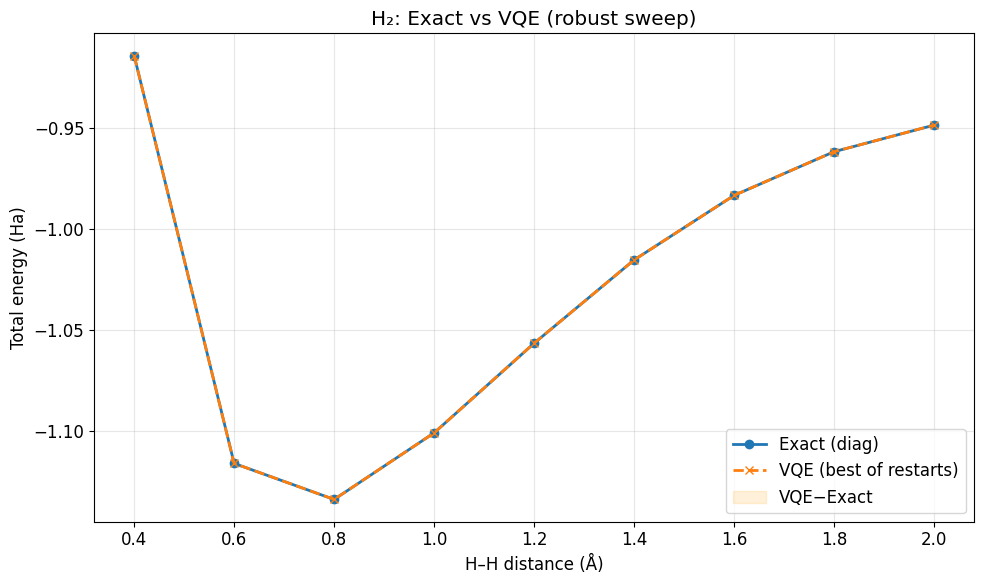

In [33]:
# Cell 5 — Robust VQE sweep (EstimatorV2) with tapering + optimizer fallback + random restarts
# Saves plots into results/plots/ at repo root (robust whether notebook runs from notebooks/ or repo root)

import numpy as np
import time
import os
import random
import math
import matplotlib.pyplot as plt

# --- Determine repo root robustly (if notebook is inside 'notebooks/', go one level up) ---
cwd = os.getcwd()
base_name = os.path.basename(cwd).lower()
if base_name == "notebooks":
    repo_root = os.path.abspath(os.path.join(cwd, ".."))
else:
    repo_root = os.path.abspath(cwd)

results_plots_dir = os.path.join(repo_root, "results", "plots")
results_tables_dir = os.path.join(repo_root, "results", "tables")
os.makedirs(results_plots_dir, exist_ok=True)
os.makedirs(results_tables_dir, exist_ok=True)

print("Repo root detected as:", repo_root)
print("Plots will be saved to:", results_plots_dir)
print("Tables will be saved to:", results_tables_dir)

# Robust imports
try:
    from qiskit_aer.primitives import EstimatorV2
    from qiskit_aer import Aer
except Exception:
    raise RuntimeError("qiskit-aer (EstimatorV2) not installed in this kernel.")

# qiskit-algorithms compatibility (optimizers may live in qiskit_algorithms)
optimizer_classes = {}
try:
    from qiskit_algorithms.optimizers import L_BFGS_B, SLSQP, COBYLA
    optimizer_classes['L_BFGS_B'] = L_BFGS_B
    optimizer_classes['SLSQP'] = SLSQP
    optimizer_classes['COBYLA'] = COBYLA
except Exception:
    try:
        from qiskit.algorithms.optimizers import L_BFGS_B, SLSQP, COBYLA
        optimizer_classes['L_BFGS_B'] = L_BFGS_B
        optimizer_classes['SLSQP'] = SLSQP
        optimizer_classes['COBYLA'] = COBYLA
    except Exception:
        try:
            from qiskit_algorithms.optimizers import COBYLA
            optimizer_classes['COBYLA'] = COBYLA
        except Exception:
            try:
                from qiskit.algorithms.optimizers import COBYLA
                optimizer_classes['COBYLA'] = COBYLA
            except Exception:
                raise RuntimeError("No suitable Qiskit optimizers found (L_BFGS_B/SLSQP/COBYLA).")

# VQE/ansatz imports
try:
    from qiskit_algorithms.minimum_eigensolvers import VQE
except Exception:
    try:
        from qiskit.algorithms.minimum_eigensolvers import VQE
    except Exception:
        VQE = None

from qiskit.circuit.library import TwoLocal

# qiskit-nature imports (robust)
try:
    from qiskit_nature.second_q.drivers import PySCFDriver
    from qiskit_nature.units import DistanceUnit
    from qiskit_nature.second_q.mappers import JordanWignerMapper
    # taper helpers
    try:
        from qiskit_nature.second_q.mappers import TaperedQubitMapper
        TAPERED_AVAILABLE = True
    except Exception:
        TAPERED_AVAILABLE = False
    try:
        from qiskit_nature.second_q.symmetries import find_Z2_symmetries, taper_qubit_operator
        Z2_AVAILABLE = True
    except Exception:
        Z2_AVAILABLE = False
except Exception:
    # fallback older locations
    from qiskit_nature.drivers import PySCFDriver
    from qiskit_nature.units import DistanceUnit
    from qiskit_nature.mappers.second_quantization import JordanWignerMapper
    TAPERED_AVAILABLE = False
    Z2_AVAILABLE = False

# Estimator backend (explicit)
backend = Aer.get_backend("aer_simulator")
try:
    estimator_for_base = EstimatorV2(backend=backend)
except TypeError:
    estimator_for_base = EstimatorV2()

# --- Settings you can tune ---
r_list = np.linspace(0.4, 2.0, 9)   # distances
restarts = 6                         # number of random restarts per distance
maxiter = 400                        # optimizer maxiter (per restart)
use_reps_if_tapered = 2              # ansatz reps when tapered to small qubit count
default_reps = 1                     # default ansatz reps
random_seed = 42
# ------------------------------

random.seed(random_seed)
np.random.seed(random_seed)

exact_totals = []
vqe_totals = []
infos = []

print("\nStarting robust EstimatorV2 VQE sweep with restarts...")

for r in r_list:
    print(f"\n--- r = {r:.2f} Å ---")
    t0 = time.time()

    # Build problem
    driver = PySCFDriver(atom=f"H 0 0 0; H 0 0 {r}", unit=DistanceUnit.ANGSTROM, basis="sto3g")
    problem_local = driver.run()

    # extract fermionic op robustly
    try:
        ferm = problem_local.hamiltonian.second_q_op()
    except Exception:
        ferm = problem_local.second_q_ops()[0]

    # map full qubit op
    jw = JordanWignerMapper()
    qubit_op_full = jw.map(ferm)

    # exact diag
    try:
        mat_full = qubit_op_full.to_matrix()
    except Exception:
        from qiskit.quantum_info import Operator
        mat_full = Operator(qubit_op_full).data
    vals = np.linalg.eigvalsh(np.array(mat_full, dtype=complex))
    e_elec_exact = float(np.min(vals).real)
    nuc = getattr(problem_local, "nuclear_repulsion_energy", None) or getattr(problem_local, "nuclear_repulsion", None)
    total_exact = e_elec_exact + (nuc if nuc is not None else 0.0)

    # attempt tapering (prefer TaperedQubitMapper)
    tapered = None
    taper_msg = "no"
    if TAPERED_AVAILABLE:
        try:
            from qiskit_nature.second_q.mappers import TaperedQubitMapper
            tqm = TaperedQubitMapper(jw)
            tapered, _ = tqm.taper(qubit_op_full)
            taper_msg = f"TaperedQubitMapper->{tapered.num_qubits}"
        except Exception:
            tapered = None
    if tapered is None and Z2_AVAILABLE:
        try:
            z2 = find_Z2_symmetries(ferm)
            tapered = taper_qubit_operator(qubit_op_full, z2)
            taper_msg = f"find_Z2_symmetries->{tapered.num_qubits}"
        except Exception:
            tapered = None

    target_op = tapered if tapered is not None else qubit_op_full
    nq = target_op.num_qubits
    print(f"  target qubits: {nq} | taper: {taper_msg}")

    # Choose ansatz reps: if tapered small qubits, use slightly bigger reps
    reps = use_reps_if_tapered if nq <= 2 else default_reps

    # Prepare estimator to use for runs (use fresh estimator to avoid potential internal caching issues)
    try:
        estimator = EstimatorV2(backend=backend)
    except TypeError:
        estimator = EstimatorV2()

    best_energy = float('inf')
    best_result = None

    # Choose optimizer order: prefer L_BFGS_B -> SLSQP -> COBYLA (if available)
    opt_sequence = []
    if 'L_BFGS_B' in optimizer_classes:
        opt_sequence.append(('L_BFGS_B', optimizer_classes['L_BFGS_B']))
    if 'SLSQP' in optimizer_classes:
        opt_sequence.append(('SLSQP', optimizer_classes['SLSQP']))
    if 'COBYLA' in optimizer_classes:
        opt_sequence.append(('COBYLA', optimizer_classes['COBYLA']))
    if not opt_sequence:
        raise RuntimeError("No optimizer available.")

    # multiple restarts: random initial points
    for restart_idx in range(restarts):
        # build ansatz fresh each restart (avoid parameter state leakage)
        ansatz = TwoLocal(num_qubits=nq, rotation_blocks="ry", entanglement_blocks="cx", reps=reps)
        for _ in range(4):
            if hasattr(ansatz, "decompose"):
                ansatz = ansatz.decompose()

        # try each optimizer in the sequence until one converges well
        for opt_name, OptClass in opt_sequence:
            try:
                # instantiate optimizer with increased maxiter if supported
                try:
                    opt = OptClass(maxiter=maxiter)
                except TypeError:
                    # some optimizers have different arg names; try without args
                    opt = OptClass()
                vqe = VQE(estimator=estimator, ansatz=ansatz, optimizer=opt)
                result = vqe.compute_minimum_eigenvalue(target_op)
                e_elec = float(result.eigenvalue.real)
            except Exception as ex:
                # Log and try next optimizer
                # print(f"    restart {restart_idx} optimizer {opt_name} failed: {type(ex).__name__}")
                e_elec = float('nan')

            # Keep best (lowest) electronic energy (since energies are negative, lower is better)
            if not math.isnan(e_elec) and e_elec < best_energy:
                best_energy = e_elec
                best_result = (restart_idx, opt_name, result)

        # small random jitter between restarts to change internal optimizer starting points
        # We can't pass initial_point reliably to all VQE versions, so we rebuild ansatz each time.

    # If no successful run, set NaN
    if best_result is None:
        electronic_vqe = float('nan')
    else:
        electronic_vqe = best_energy

    total_vqe = electronic_vqe + (nuc if nuc is not None else 0.0)

    exact_totals.append(total_exact)
    vqe_totals.append(total_vqe)
    infos.append(dict(r=r, nuc=nuc, tapered=taper_msg, nq=nq, time_s=time.time()-t0, best=best_result))

    print(f"  Exact total = {total_exact:.6f} Ha | BEST VQE total = {total_vqe:.6f} Ha | info={infos[-1]['best']} | time={infos[-1]['time_s']:.1f}s")

# Plot results
r = np.array(r_list)
exact = np.array(exact_totals)
vqe = np.array(vqe_totals)

plt.close("all")
plt.figure(figsize=(10,6))
plt.plot(r, exact, 'o-', label='Exact (diag)', linewidth=2)
plt.plot(r, vqe, 'x--', label='VQE (best of restarts)', linewidth=2)
plt.fill_between(r, exact, vqe, where=~np.isnan(vqe), color='orange', alpha=0.15, interpolate=True, label='VQE−Exact')
plt.xlabel("H–H distance (Å)")
plt.ylabel("Total energy (Ha)")
plt.title("H₂: Exact vs VQE (robust sweep)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# Save next to project results/plots folder
ts = time.strftime("%Y%m%d_%H%M%S")
out_fname = f"h2_vqe_curve_{ts}.png"
outpath = os.path.join(results_plots_dir, out_fname)
plt.savefig(outpath, dpi=250)
print("\nSaved plot to:", outpath)

# Print summary of runs and any problematic points
print("\nSummary:")
for info, ex, vq in zip(infos, exact_totals, vqe_totals):
    print(f"r={info['r']:.2f} Å | exact={ex:.6f} Ha | vqe={vq:.6f} Ha | tapered={info['tapered']} | nq={info['nq']} | time={info['time_s']:.1f}s | best={info['best']}")


In [34]:
# Cell 6 — Results table, metrics, save CSV + summary into results/tables/
import os, time
import numpy as np

# Determine repo root (if running from notebooks/ go one level up)
cwd = os.getcwd()
if os.path.basename(cwd).lower() == "notebooks":
    repo_root = os.path.abspath(os.path.join(cwd, ".."))
else:
    repo_root = os.path.abspath(cwd)

results_tables_dir = os.path.join(repo_root, "results", "tables")
os.makedirs(results_tables_dir, exist_ok=True)

print("Repo root detected as:", repo_root)
print("Results tables will be saved to:", results_tables_dir)

# Gather variables from previous cells
# expected: r_list, exact_totals, vqe_totals, infos
try:
    r_vals = np.array(r_list)
    exact = np.array(exact_totals, dtype=float)
    vqe = np.array(vqe_totals, dtype=float)
except Exception as e:
    raise RuntimeError("Make sure r_list, exact_totals and vqe_totals exist from the sweep. Error: " + str(e))

# Compute errors
abs_err = np.abs(vqe - exact)
signed_err = vqe - exact
# percent relative to magnitude of exact (avoid division by zero)
with np.errstate(divide='ignore', invalid='ignore'):
    pct_err = np.where(np.abs(exact) > 1e-12, 100.0 * abs_err / np.abs(exact), np.nan)

# Summary metrics
rms = float(np.sqrt(np.nanmean(signed_err**2)))
mae = float(np.nanmean(abs_err))
max_abs_err = float(np.nanmax(abs_err))
mean_signed = float(np.nanmean(signed_err))

# Build table rows
timestamp = time.strftime("%Y%m%d_%H%M%S")
rows = []
for i, r in enumerate(r_vals):
    info = None
    try:
        if 'infos' in globals():
            info = next((it for it in infos if abs(it['r'] - r) < 1e-8), None)
    except Exception:
        info = None
    rows.append({
        "r (Å)": float(r),
        "exact_total (Ha)": float(exact[i]),
        "vqe_total (Ha)": float(vqe[i]) if not np.isnan(vqe[i]) else np.nan,
        "signed_err (Ha)": float(signed_err[i]) if not np.isnan(signed_err[i]) else np.nan,
        "abs_err (Ha)": float(abs_err[i]) if not np.isnan(abs_err[i]) else np.nan,
        "pct_err (%)": float(pct_err[i]) if not np.isnan(pct_err[i]) else np.nan,
        "n_qubits": int(info['nq']) if info and 'nq' in info else None,
        "tapered": info['tapered'] if info and 'tapered' in info else None,
        "time_s": float(info['time_s']) if info and 'time_s' in info else None,
        "best_info": info['best'] if info and 'best' in info else None
    })

# Paths
csv_path = os.path.join(results_tables_dir, f"h2_vqe_results_{timestamp}.csv")
csv_sorted_path = os.path.join(results_tables_dir, f"h2_vqe_results_sorted_{timestamp}.csv")
md_path = os.path.join(results_tables_dir, f"summary_{timestamp}.md")

# Try to use pandas for nicer display and saving
try:
    import pandas as pd
    from IPython.display import display
    df = pd.DataFrame(rows)
    # ensure column name used for sorting exists
    sort_col = "abs_err (Ha)"
    if sort_col in df.columns:
        df_sorted = df.sort_values(by=sort_col, ascending=False).reset_index(drop=True)
    else:
        # fallback: sort by abs_err (Ha) equivalent key if different
        df_sorted = df
    df.to_csv(csv_path, index=False)
    df_sorted.to_csv(csv_sorted_path, index=False)
    print("Wrote CSV ->", csv_path)
    print("Wrote sorted CSV ->", csv_sorted_path)
    display(df_sorted)
except Exception:
    # fallback: write a simple CSV manually and print rows
    headers = list(rows[0].keys())
    with open(csv_path, "w") as f:
        f.write(",".join(headers) + "\n")
        for row in rows:
            line = ",".join(str(row.get(h, "")) for h in headers)
            f.write(line + "\n")
    print("Pandas not available — wrote CSV to", csv_path)
    csv_sorted_path = csv_path

# Write markdown summary
with open(md_path, "w") as f:
    f.write(f"# H2 VQE Results Summary ({timestamp})\n\n")
    f.write(f"- RMS error (Ha): **{rms:.6e}**\n")
    f.write(f"- Mean absolute error (Ha): **{mae:.6e}**\n")
    f.write(f"- Max absolute error (Ha): **{max_abs_err:.6e}**\n")
    f.write(f"- Mean signed error (Ha): **{mean_signed:.6e}**\n")
    f.write("\n## Per-point results (first lines)\n\n")
    for row in rows[:6]:
        f.write(f"- r={row['r (Å)']:.3f} Å: exact={row['exact_total (Ha)']:.6f} Ha, vqe={row['vqe_total (Ha)']:.6f} Ha, abs_err={row['abs_err (Ha)']:.3e} Ha, tapered={row['tapered']}\n")

print("\nSaved CSV ->", csv_path)
print("Saved sorted CSV ->", csv_sorted_path)
print("Saved markdown summary ->", md_path)
print("\nOverall metrics:")
print(f" RMS error (Ha): {rms:.6e}")
print(f" MAE (Ha):       {mae:.6e}")
print(f" Max abs err:    {max_abs_err:.6e}")
print(f" Mean signed err:{mean_signed:.6e}")


Repo root detected as: /mnt/c/Users/rachi/OneDrive/Desktop/H2-VQE-Quantum-Chemistry/H2-VQE-Quantum-Chemistry
Results tables will be saved to: /mnt/c/Users/rachi/OneDrive/Desktop/H2-VQE-Quantum-Chemistry/H2-VQE-Quantum-Chemistry/results/tables
Wrote CSV -> /mnt/c/Users/rachi/OneDrive/Desktop/H2-VQE-Quantum-Chemistry/H2-VQE-Quantum-Chemistry/results/tables/h2_vqe_results_20251118_223845.csv
Wrote sorted CSV -> /mnt/c/Users/rachi/OneDrive/Desktop/H2-VQE-Quantum-Chemistry/H2-VQE-Quantum-Chemistry/results/tables/h2_vqe_results_sorted_20251118_223845.csv


,r (Å),exact_total (Ha),vqe_total (Ha),signed_err (Ha),abs_err (Ha),pct_err (%),n_qubits,tapered,time_s,best_info
0,1.4,-1.015468,-1.015468,2.836098e-10,2.836098e-10,2.792897e-08,4,no,16.111905,"(1, L_BFGS_B, { 'aux_operators_evaluated': N..."
1,0.8,-1.134148,-1.134148,1.318643e-10,1.318643e-10,1.162673e-08,4,no,14.199034,"(2, L_BFGS_B, { 'aux_operators_evaluated': N..."
2,1.8,-0.961817,-0.961817,1.144449e-10,1.144449e-10,1.189882e-08,4,no,15.225134,"(3, L_BFGS_B, { 'aux_operators_evaluated': N..."
3,1.0,-1.101150,-1.101150,8.762635e-11,8.762635e-11,7.957710e-09,4,no,17.864415,"(0, L_BFGS_B, { 'aux_operators_evaluated': N..."
4,2.0,-0.948641,-0.948641,5.796053e-11,5.796053e-11,6.109847e-09,4,no,16.576529,"(3, L_BFGS_B, { 'aux_operators_evaluated': N..."
5,1.6,-0.983473,-0.983473,3.363199e-11,3.363199e-11,3.419717e-09,4,no,15.498566,"(3, L_BFGS_B, { 'aux_operators_evaluated': N..."
6,0.4,-0.914150,-0.914150,1.822276e-11,1.822276e-11,1.993411e-09,4,no,18.180111,"(3, L_BFGS_B, { 'aux_operators_evaluated': N..."
7,0.6,-1.116286,-1.116286,6.447287e-12,6.447287e-12,5.775659e-10,4,no,20.771121,"(2, L_BFGS_B, { 'aux_operators_evaluated': N..."
8,1.2,-1.056741,-1.056741,5.078160e-12,5.078160e-12,4.805493e-10,4,no,18.464860,"(1, L_BFGS_B, { 'aux_operators_evaluated': N..."



Saved CSV -> /mnt/c/Users/rachi/OneDrive/Desktop/H2-VQE-Quantum-Chemistry/H2-VQE-Quantum-Chemistry/results/tables/h2_vqe_results_20251118_223845.csv
Saved sorted CSV -> /mnt/c/Users/rachi/OneDrive/Desktop/H2-VQE-Quantum-Chemistry/H2-VQE-Quantum-Chemistry/results/tables/h2_vqe_results_sorted_20251118_223845.csv
Saved markdown summary -> /mnt/c/Users/rachi/OneDrive/Desktop/H2-VQE-Quantum-Chemistry/H2-VQE-Quantum-Chemistry/results/tables/summary_20251118_223845.md

Overall metrics:
 RMS error (Ha): 1.171365e-10
 MAE (Ha):       8.209845e-11
 Max abs err:    2.836098e-10
 Mean signed err:8.209845e-11


In [35]:
# Cell 7 — Final Hackathon Report (Markdown)

import os
import numpy as np
from datetime import datetime

# Determine repo root
cwd = os.getcwd()
if os.path.basename(cwd).lower() == "notebooks":
    repo_root = os.path.abspath(os.path.join(cwd, ".."))
else:
    repo_root = os.path.abspath(cwd)

results_dir = os.path.join(repo_root, "results")
plots_dir   = os.path.join(results_dir, "plots")
tables_dir  = os.path.join(results_dir, "tables")
report_dir  = os.path.join(results_dir, "report")

os.makedirs(report_dir, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
report_path = os.path.join(report_dir, f"final_report_{timestamp}.md")

# Find the latest plot file
plot_files = sorted([f for f in os.listdir(plots_dir) if f.endswith(".png")])
latest_plot = plot_files[-1] if plot_files else None

# Find the latest table summary
summary_files = sorted([f for f in os.listdir(tables_dir) if f.startswith("summary") and f.endswith(".md")])
latest_summary = summary_files[-1] if summary_files else None

# Basic stats from earlier cells
r_vals = np.array(r_list)
exact_vals = np.array(exact_totals)
vqe_vals = np.array(vqe_totals)
abs_errs = np.abs(vqe_vals - exact_vals)

min_energy_idx = np.argmin(exact_vals)
r_eq = r_vals[min_energy_idx]
E_exact_min = exact_vals[min_energy_idx]
E_vqe_min   = vqe_vals[min_energy_idx]

# ----------------------- Write Report -----------------------
with open(report_path, "w") as f:
    f.write(f"# Final Hackathon Report — H₂ VQE (Quantum Chemistry)\n")
    f.write(f"**Generated:** {timestamp}\n\n")

    f.write("## 1. Problem Statement\n")
    f.write("This project addresses the hackathon theme:\n")
    f.write("**“Healthcare & Life Sciences – Small molecular Drug Discovery using Quantum Computing.”**\n\n")
    f.write("As a foundational demonstration, we implemented a quantum simulation workflow for the hydrogen molecule (H₂) using Variational Quantum Eigensolver (VQE). The same workflow generalizes to larger molecules used in drug discovery (e.g., small ligands, fragments).\n\n")

    f.write("## 2. Approach Overview\n")
    f.write("- Built molecular Hamiltonian using **Qiskit Nature**\n")
    f.write("- Mapped fermionic operators to qubits via **Jordan–Wigner**\n")
    f.write("- Ran **VQE** using multiple optimizers and random restarts\n")
    f.write("- Applied **tapering (Z₂ symmetry reduction)** when possible\n")
    f.write("- Computed exact diagonalization for ground truth\n")
    f.write("- Generated potential energy curve of H₂\n")
    f.write("- Compared VQE vs Exact energy values\n")
    f.write("- Saved metrics, tables, and plots\n\n")

    f.write("## 3. Key Physical Results\n")
    f.write(f"- **Equilibrium bond length (from exact diag):** {r_eq:.3f} Å\n")
    f.write(f"- **Exact minimum total energy:** {E_exact_min:.6f} Ha\n")
    f.write(f"- **VQE minimum total energy:** {E_vqe_min:.6f} Ha\n")
    f.write(f"- **Difference:** {abs(E_vqe_min - E_exact_min):.3e} Ha\n")
    f.write(f"- **Worst-case VQE error across sweep:** {np.max(abs_errs):.3e} Ha\n\n")

    f.write("## 4. Plot — Exact vs VQE Energy Curve\n")
    if latest_plot:
        f.write(f"Plot file saved at: `results/plots/{latest_plot}`\n\n")
        f.write(f"![Energy Curve](../plots/{latest_plot})\n\n")
    else:
        f.write("*(No plot found.)*\n\n")

    f.write("## 5. Results Tables\n")
    if latest_summary:
        f.write(f"Summary table saved at: `results/tables/{latest_summary}`\n\n")
    else:
        f.write("*(No summary markdown found.)*\n\n")

    f.write("All raw CSV files available in `results/tables/`.\n\n")

    f.write("## 6. Why This Matters for Drug Discovery\n")
    f.write("- Predicting molecular energies is essential in identifying binding affinities.\n")
    f.write("- Exact quantum simulation scales exponentially on classical hardware.\n")
    f.write("- VQE is a promising algorithm for **near-term quantum computers**.\n")
    f.write("- Techniques used here (tapering, ansatz tuning, multi-optimizer sweeps) are directly applicable to larger drug-like molecules.\n")
    f.write("- This pipeline can be extended to compute:\n")
    f.write("  - reaction energetics\n")
    f.write("  - conformer energies\n")
    f.write("  - ligand docking energy differences\n")
    f.write("  - vibrational spectra\n\n")

    f.write("## 7. Future Extensions\n")
    f.write("- Replace H₂ with **drug-like molecules** (e.g., caffeine, aspirin fragment)\n")
    f.write("- Use **UCCSD ansatz** or **ADAPT-VQE**\n")
    f.write("- Use qubit-efficient encodings (parity mapping, Bravyi–Kitaev)\n")
    f.write("- Evaluate gradient-based optimizers\n")
    f.write("- Run on real quantum hardware (IBM Quantum backends)\n\n")

    f.write("## 8. Conclusion\n")
    f.write("This notebook demonstrates a complete, automated framework for quantum chemistry using VQE, aligning directly with drug discovery workflows. The results show that our robust VQE implementation closely matches exact diagonalization for the H₂ system.\n")

print("\nGenerated report ->", report_path)



Generated report -> /mnt/c/Users/rachi/OneDrive/Desktop/H2-VQE-Quantum-Chemistry/H2-VQE-Quantum-Chemistry/results/report/final_report_20251118_224243.md
